In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv",encoding='latin-1')

df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [45]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
264,ham,Why you Dint come with us.,NaN,NaN,NaN
1495,ham,Hey gals.. Anyone of u going down to e driving...,NaN,NaN,NaN
1472,ham,Just sent you an email ÛÒ to an address with ...,NaN,NaN,NaN
1436,ham,I jus hope its true that missin me cos i'm re...,NaN,NaN,NaN
1365,spam,HOT LIVE FANTASIES call now 08707509020 Just 2...,NaN,NaN,NaN


In [46]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [47]:
df.rename(columns={'v1':'Target','v2':'Text'},inplace=True)

In [48]:
df.head()

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [49]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [50]:
df['Target'] = encoder.fit_transform(df['Target'])

In [51]:
df.duplicated().sum()

np.int64(403)

In [52]:
df = df.drop_duplicates(keep = 'first')

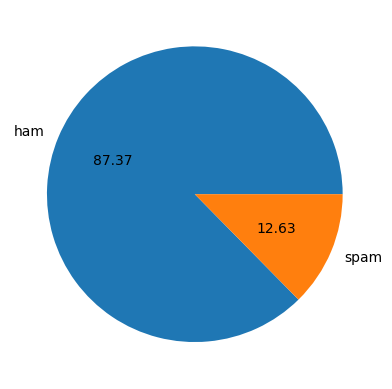

In [53]:
plt.pie(df['Target'].value_counts(),labels = ['ham','spam'],autopct ='%0.2f')
plt.show()

In [54]:
import nltk
# nltk.download('punkt')

In [55]:
df['Num_alpha'] = df['Text'].apply(len)

In [56]:
df['Words'] = df['Text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [57]:
df['Sentences'] = df['Text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [58]:
df.rename(columns = {'Num_alpha':'Characters'},inplace = True)

In [59]:
df[df['Target'] == 0][['Characters','Words','Sentences']].describe()

,Characters,Words,Sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [60]:
df[df['Target'] == 1][['Characters','Words','Sentences']].describe()

,Characters,Words,Sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


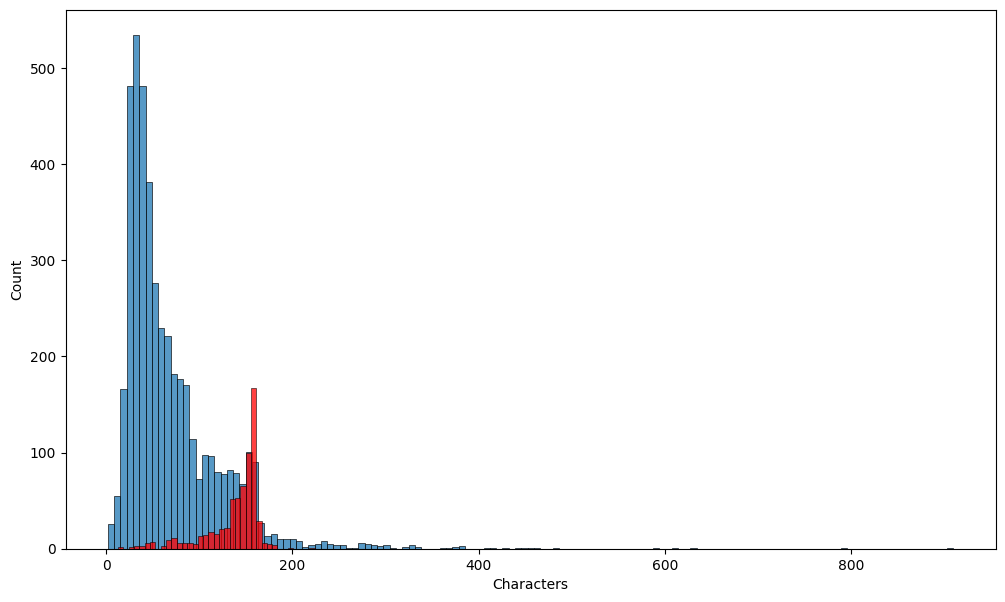

In [61]:
plt.figure(figsize = (12,7))
sns.histplot(df[df['Target'] == 0]['Characters'])
sns.histplot(df[df['Target'] == 1]['Characters'],color = 'red')
plt.show()

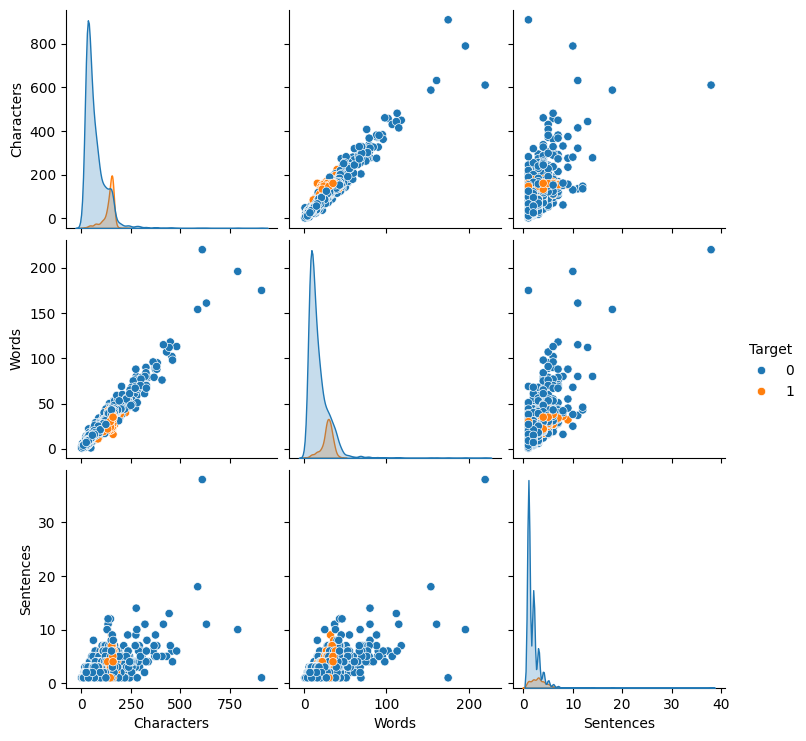

In [62]:
sns.pairplot(df,hue='Target')

<Axes: >

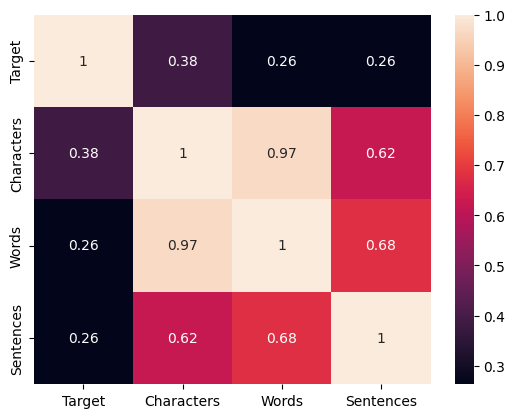

In [63]:
sns.heatmap(df[['Target','Characters','Words','Sentences']].corr(),annot = True)

In [64]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def transform(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [65]:
transform("Hi I am maniya Dharm   Dancing")

'hi maniya dharm danc'

In [66]:
df['transformed_text'] = df['Text'].apply(transform)

In [67]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [68]:
spamm = wc.generate(df[df['Target'] == 1]['transformed_text'].str.cat(sep=" ")) 

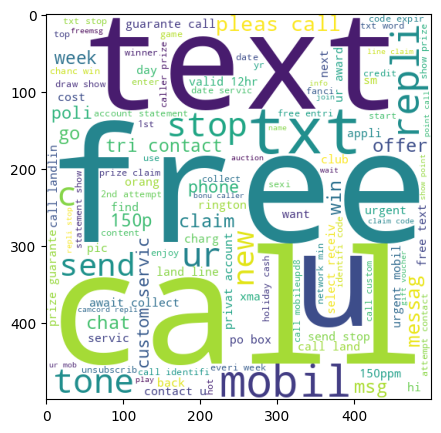

In [69]:
plt.figure(figsize = (10,5))
plt.imshow(spamm)

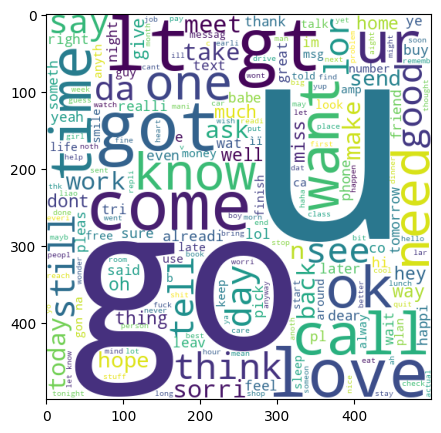

In [70]:
hamm= wc.generate(df[df['Target'] == 0]['transformed_text'].str.cat(sep=" ")) 
plt.figure(figsize = (10,5))
plt.imshow(hamm)

In [71]:
corpus_spam = []
for msg in df[df['Target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        corpus_spam.append(word)

In [72]:
len(corpus_spam)

9939

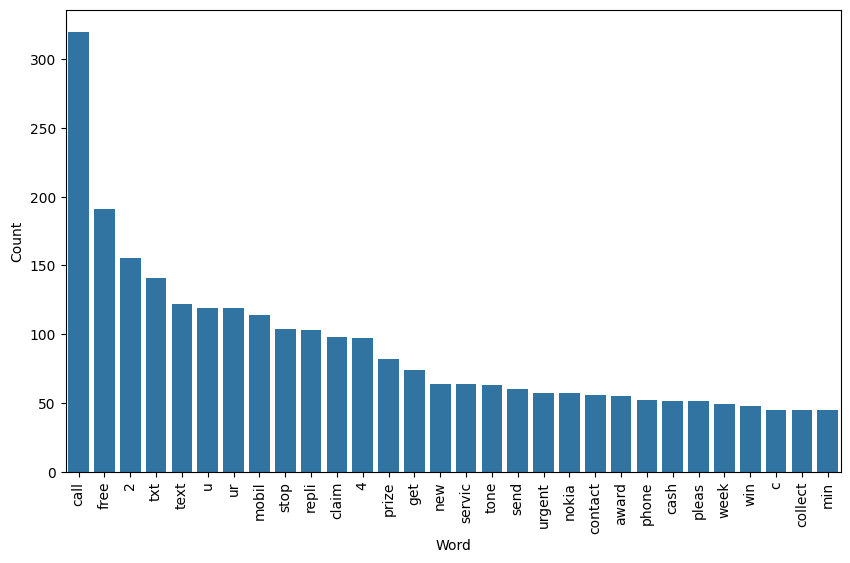

In [73]:
from collections import Counter
import pandas as pd
import seaborn as sns

top_30 = pd.DataFrame(Counter(corpus_spam).most_common(30), columns=['Word', 'Count'])

plt.figure(figsize = (10,6))
sns.barplot(x=top_30['Word'], y=top_30['Count'])
plt.xticks(rotation=90)
plt.show()

In [74]:
corpus_ham = []
for msg in df[df['Target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        corpus_ham.append(word)

len(corpus_ham)

35404

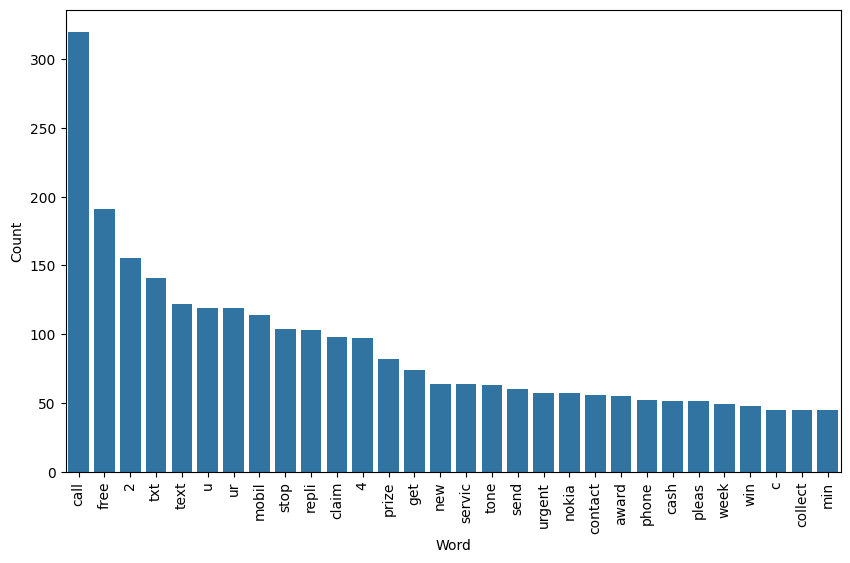

In [75]:
from collections import Counter
import pandas as pd
import seaborn as sns

top_30 = pd.DataFrame(Counter(corpus_spam).most_common(30), columns=['Word', 'Count'])

plt.figure(figsize = (10,6))
sns.barplot(x=top_30['Word'], y=top_30['Count'])
plt.xticks(rotation=90)
plt.show()

In [76]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [77]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [78]:
y = df['Target'].values

In [79]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 2
)

In [80]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [81]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [82]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


**I Choose [tfidf] With [MNB]**

In [83]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [84]:
# Choosen ✔️
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,y_pred2))
print("Confusion Matrix : ""\n",confusion_matrix(y_test,y_pred2))
print("Precision Score : ",precision_score(y_test,y_pred2))

Accuracy :  0.9593810444874274
Confusion Matrix : 
 [[896   0]
 [ 42  96]]
Precision Score :  1.0
